LDA С ПОДРОБНЫМ СРАВНЕНИЕМ С РАСЧЕТАМИ ИЗ ИЗОБРАЖЕНИЯ
Изображение содержит:
1. Коэффициенты A = [0.15672, 3.594781, -1.2915]
2. Значения F1 и F2
3. Порог F_all = 31.87564
4. Разности F0 - F_all
ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA) - СРАВНЕНИЕ С ИЗОБРАЖЕНИЕМ

МЕНЮ ВЫБОРА ТЕСТА
1. Тест на оригинальном примере с предприятиями (сравнение с изображением)
2. Тест на датасете диабета
3. Выход
ТЕСТ: ОРИГИНАЛЬНЫЙ ПРИМЕР С ПРЕДПРИЯТИЯМИ

ИСХОДНЫЕ ДАННЫЕ:
Класс 1: Передовые предприятия (4 объекта)
X1 = 
[[224.228  17.115  22.981]
 [151.827  14.904  21.481]
 [147.313  13.627  18.669]
 [152.253  10.545  10.199]]

Класс 2: Отстающие предприятия (5 объектов)
X2 = 
[[46.757  4.428 11.124]
 [29.033  5.51   6.091]
 [52.134  4.214 11.842]
 [37.05   5.527 11.873]
 [63.979  4.211 12.86 ]]

Тестовые объекты: 3 предприятия для классификации
X0 = 
[[55.451  9.592 12.84 ]
 [78.575 11.727 15.535]
 [98.353 17.572 20.458]]

ВЫПОЛНЕНИЕ РАСЧЕТА LDA С СРАВНЕНИЕМ С ИЗОБРАЖЕНИЕМ
ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA) 

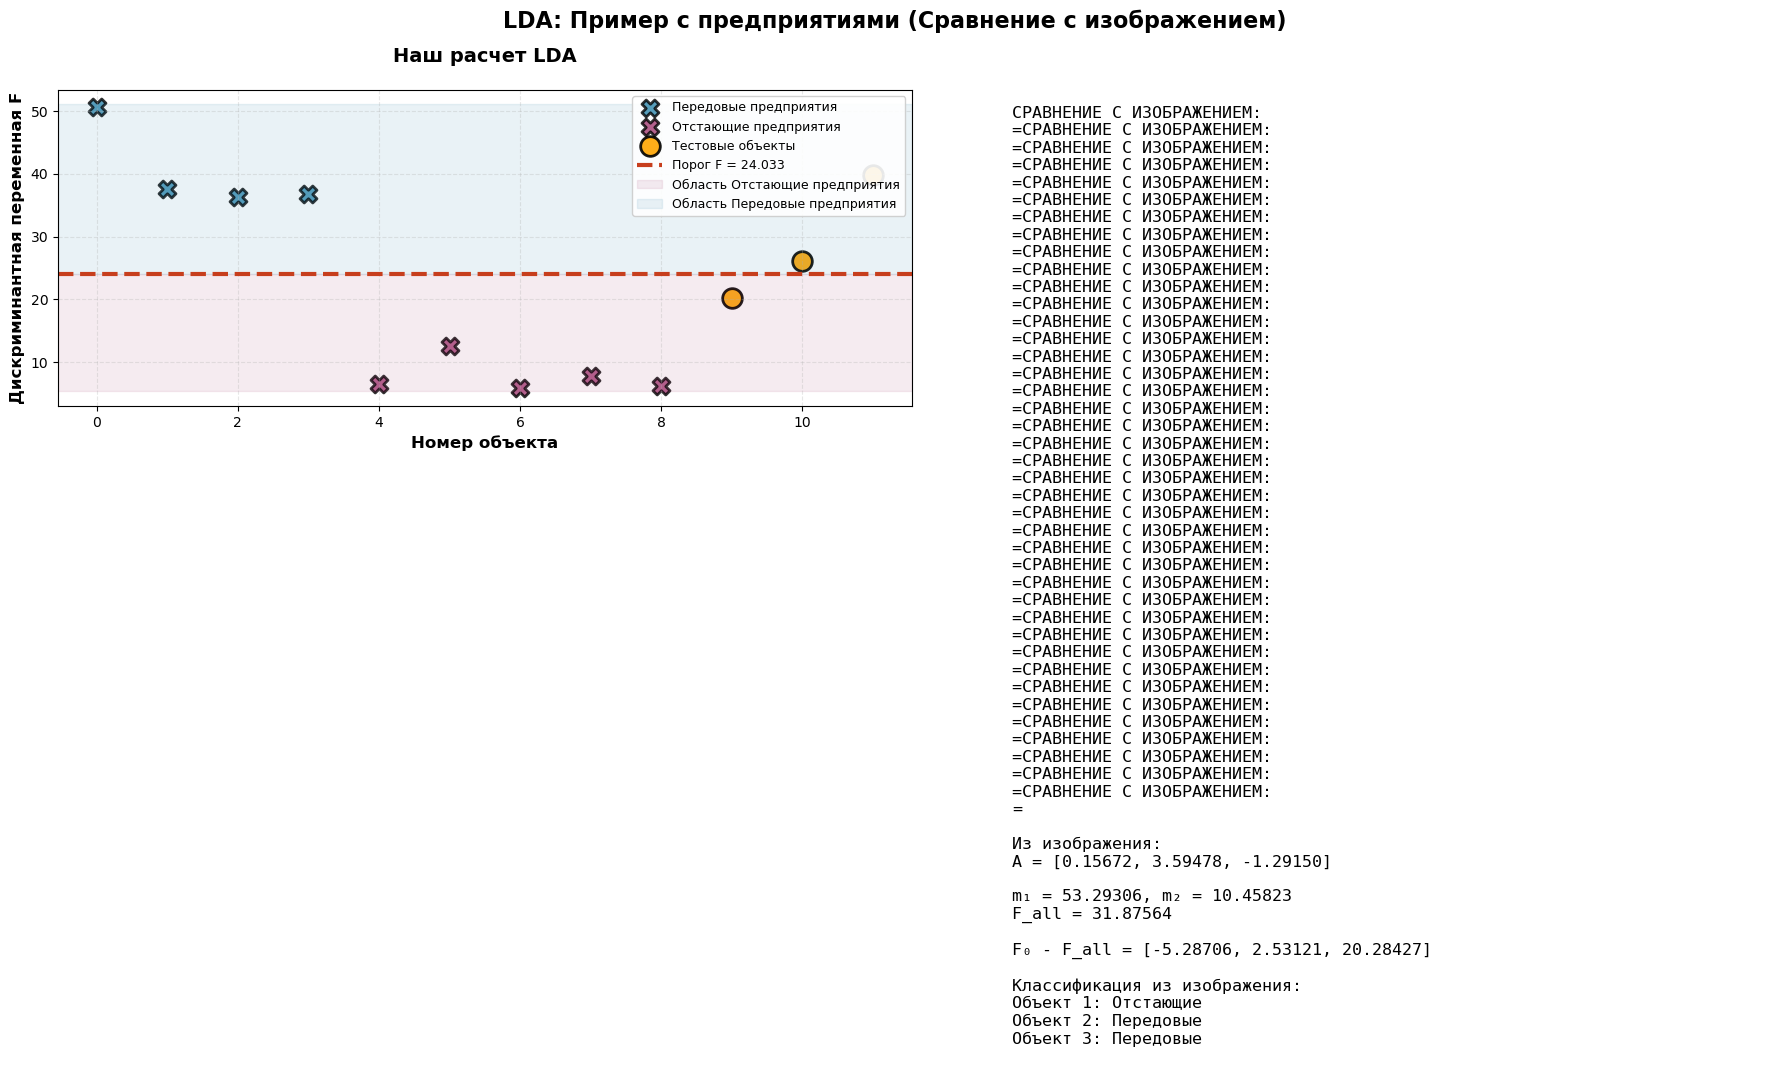


МЕНЮ ВЫБОРА ТЕСТА
1. Тест на оригинальном примере с предприятиями (сравнение с изображением)
2. Тест на датасете диабета
3. Выход

Неверный выбор.

МЕНЮ ВЫБОРА ТЕСТА
1. Тест на оригинальном примере с предприятиями (сравнение с изображением)
2. Тест на датасете диабета
3. Выход
ТЕСТ: ОРИГИНАЛЬНЫЙ ПРИМЕР С ПРЕДПРИЯТИЯМИ

ИСХОДНЫЕ ДАННЫЕ:
Класс 1: Передовые предприятия (4 объекта)
X1 = 
[[224.228  17.115  22.981]
 [151.827  14.904  21.481]
 [147.313  13.627  18.669]
 [152.253  10.545  10.199]]

Класс 2: Отстающие предприятия (5 объектов)
X2 = 
[[46.757  4.428 11.124]
 [29.033  5.51   6.091]
 [52.134  4.214 11.842]
 [37.05   5.527 11.873]
 [63.979  4.211 12.86 ]]

Тестовые объекты: 3 предприятия для классификации
X0 = 
[[55.451  9.592 12.84 ]
 [78.575 11.727 15.535]
 [98.353 17.572 20.458]]

ВЫПОЛНЕНИЕ РАСЧЕТА LDA С СРАВНЕНИЕМ С ИЗОБРАЖЕНИЕМ
ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA) - СРАВНЕНИЕ С ИЗОБРАЖЕНИЕМ

РЕФЕРЕНСНЫЕ ДАННЫЕ ИЗ ИЗОБРАЖЕНИЯ:
A = [ 0.15672   3.594781 -1.2915  ]
F1 = [66.985

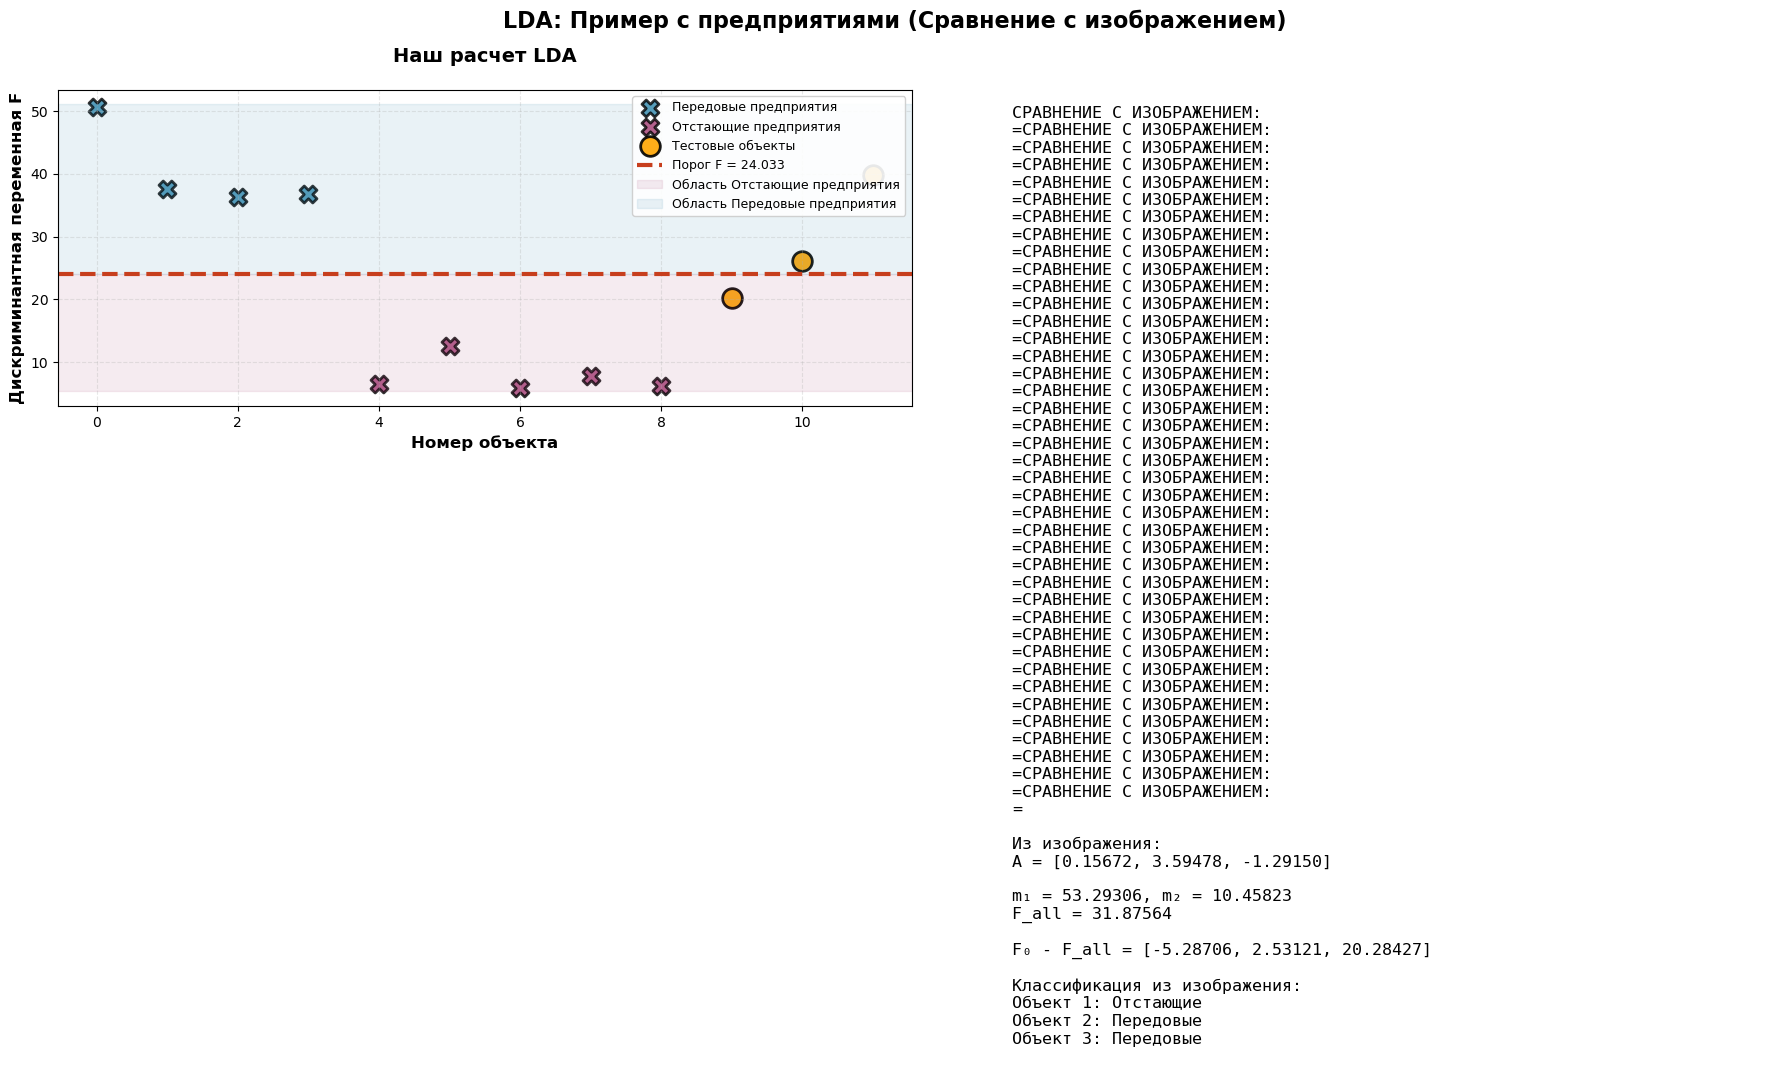


МЕНЮ ВЫБОРА ТЕСТА
1. Тест на оригинальном примере с предприятиями (сравнение с изображением)
2. Тест на датасете диабета
3. Выход

Выход из программы.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# ДАННЫЕ ИЗ ИЗОБРАЖЕНИЯ ДЛЯ СРАВНЕНИЯ
# ============================================================================
def get_reference_calculation():
    """
    Данные из предоставленного изображения для сравнения
    """
    # Коэффициенты A из изображения
    A_ref = np.array([0.15672, 3.594781, -1.2915])
    
    # Значения F1 из изображения
    F1_ref = np.array([66.98581, 49.62829, 47.96202, 48.5961])
    
    # Значения F2 из изображения
    F2_ref = np.array([8.87882, 16.49078, 8.02493, 10.34087, 8.55575])
    
    # Средние значения
    m1_ref = 53.29306
    m2_ref = 10.45823
    
    # Порог
    F_all_ref = 31.87564
    
    # Значения F0 - F_all из изображения
    F0_minus_F_ref = np.array([-5.28706, 2.53121, 20.28427])
    
    # Все значения FF из изображения (F - F_all для всех объектов)
    FF_ref = np.array([
        35.11019,    # F1[0] - F_all = 66.98581 - 31.87564 = 35.11017
        17.75265,    # F1[1] - F_all = 49.62829 - 31.87564 = 17.75265
        16.08638,    # F1[2] - F_all = 47.96202 - 31.87564 = 16.08638
        16.72046,    # F1[3] - F_all = 48.59610 - 31.87564 = 16.72046
        -22.99682,   # F2[0] - F_all = 8.87882 - 31.87564 = -22.99682
        -15.38486,   # F2[1] - F_all = 16.49078 - 31.87564 = -15.38486
        -23.85071,   # F2[2] - F_all = 8.02493 - 31.87564 = -23.85071
        -21.53477,   # F2[3] - F_all = 10.34087 - 31.87564 = -21.53477
        -23.31989,   # F2[4] - F_all = 8.55575 - 31.87564 = -23.31989
        -5.28706,    # Тестовые объекты
        2.53121,
        20.28427
    ])
    
    # Классификации (основано на FF_ref)
    # Положительные FF → Класс 1, отрицательные → Класс 2
    classifications_ref = []
    for i, ff in enumerate(FF_ref):
        if i < 4:  # Первые 4 - это обучение класса 1
            classifications_ref.append("Передовые предприятия")
        elif i < 9:  # Следующие 5 - обучение класса 2
            classifications_ref.append("Отстающие предприятия")
        else:  # Последние 3 - тестовые
            if ff > 0:
                classifications_ref.append("Передовые предприятия")
            else:
                classifications_ref.append("Отстающие предприятия")
    
    return {
        'A': A_ref,
        'F1': F1_ref,
        'F2': F2_ref,
        'm1': m1_ref,
        'm2': m2_ref,
        'F_all': F_all_ref,
        'F0_minus_F': F0_minus_F_ref,
        'FF': FF_ref,
        'classifications': classifications_ref
    }

# ============================================================================
# ОСНОВНАЯ ФУНКЦИЯ LDA С СРАВНЕНИЕМ С РЕФЕРЕНСНЫМ РАСЧЕТОМ
# ============================================================================
def lda_algorithm_with_comparison(x1, x2, x0, class1_name="Класс 1", class2_name="Класс 2", 
                                  use_unbiased_cov=True, verbose=True, show_matrices=True,
                                  compare_with_reference=False):
    """
    Алгоритм LDA для двух классов с возможностью сравнения с референсным расчетом
    """
    if verbose:
        print("=" * 80)
        print("ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA) - СРАВНЕНИЕ С ИЗОБРАЖЕНИЕМ")
        print("=" * 80)
    
    # Получаем референсные данные если нужно сравнение
    if compare_with_reference:
        ref_data = get_reference_calculation()
        print("\n" + "=" * 80)
        print("РЕФЕРЕНСНЫЕ ДАННЫЕ ИЗ ИЗОБРАЖЕНИЯ:")
        print("=" * 80)
        print(f"A = {ref_data['A'].round(6)}")
        print(f"F1 = {ref_data['F1'].round(5)}")
        print(f"F2 = {ref_data['F2'].round(5)}")
        print(f"m1 = {ref_data['m1']:.5f}, m2 = {ref_data['m2']:.5f}")
        print(f"F_all = {ref_data['F_all']:.5f}")
        print(f"F0 - F_all = {ref_data['F0_minus_F'].round(5)}")
    
    # Проверка входных данных
    if len(x1) == 0 or len(x2) == 0:
        raise ValueError("Один из классов пуст!")
    
    n1, n2 = len(x1), len(x2)
    n_features = x1.shape[1]
    
    if verbose:
        print(f"\nКласс 1: {n1} объектов")
        print(f"Класс 2: {n2} объектов")
        print(f"Тестовые объекты: {len(x0)}")
        print(f"Количество признаков: {n_features}")
    
    # ============================================================================
    # ШАГ 1: РАСЧЕТ СРЕДНИХ ВЕКТОРОВ
    # ============================================================================
    sumX1 = x1.mean(axis=0)
    sumX2 = x2.mean(axis=0)
    
    if show_matrices:
        print("\n" + "=" * 80)
        print("ШАГ 1: СРЕДНИЕ ВЕКТОРЫ")
        print("=" * 80)
        print(f"Средний вектор класса 1: {sumX1.round(6)}")
        print(f"Средний вектор класса 2: {sumX2.round(6)}")
        
        if compare_with_reference:
            print("\nСРАВНЕНИЕ:")
            # Нам нужны исходные данные чтобы вычислить средние
            print("Для вычисления средних векторов нужны исходные данные X1 и X2")
    
    # ============================================================================
    # ШАГ 2: КОВАРИАЦИОННЫЕ МАТРИЦЫ
    # ============================================================================
    divisor1 = (n1 - 1) if use_unbiased_cov else n1
    divisor2 = (n2 - 1) if use_unbiased_cov else n2
    
    X1_centered = x1 - sumX1
    X2_centered = x2 - sumX2
    
    s1 = (X1_centered.T @ X1_centered) / divisor1
    s2 = (X2_centered.T @ X2_centered) / divisor2
    
    if show_matrices:
        print(f"\nТип ковариации: {'Несмещенная (n-1)' if use_unbiased_cov else 'Смещенная (n)'}")
    
    # ============================================================================
    # ШАГ 3: ОБЩАЯ КОВАРИАЦИОННАЯ МАТРИЦА И ОБРАТНАЯ
    # ============================================================================
    S_all = 1/(n1 + n2 - 2) * (n1 * s1 + n2 * s2)
    
    try:
        SO = np.linalg.inv(S_all)
    except np.linalg.LinAlgError:
        SO = np.linalg.pinv(S_all)
    
    if show_matrices:
        print("\n" + "=" * 80)
        print("ШАГ 3: ОБРАТНАЯ МАТРИЦА")
        print("=" * 80)
        print("Обратная матрица S_all⁻¹:")
        print(SO.round(6))
        
        if compare_with_reference:
            print("\nДля проверки: A_ref = SO × (m1 - m2)")
            print(f"Изображение: A_ref = {ref_data['A'].round(6)}")
    
    # ============================================================================
    # ШАГ 4: КОЭФФИЦИЕНТЫ ДИСКРИМИНАНТНОЙ ФУНКЦИИ
    # ============================================================================
    A = SO @ (sumX1 - sumX2)
    
    print("\n" + "=" * 80)
    print("ШАГ 4: КОЭФФИЦИЕНТЫ ДИСКРИМИНАНТНОЙ ФУНКЦИИ")
    print("=" * 80)
    
    print("\n4.1. Расчет коэффициентов A = S_all⁻¹ × (m1 - m2):")
    print(f"  m1 - m2 = {sumX1.round(6)} - {sumX2.round(6)} = {(sumX1 - sumX2).round(6)}")
    print(f"\n  A = S_all⁻¹ × (m1 - m2):")
    print(f"  A =")
    for i in range(n_features):
        row_str = "  ["
        for j in range(n_features):
            row_str += f"{SO[i, j]:10.6f}  "
        row_str = row_str.rstrip()
        if i == 1:
            row_str += f"] × [{(sumX1[0] - sumX2[0]):8.6f}]   [{A[i]:10.6f}]"
        elif i == 0:
            row_str += f"]   [{(sumX1[0] - sumX2[0]):8.6f}] = [{A[i]:10.6f}]"
        else:
            row_str += f"]   [{(sumX1[0] - sumX2[0]):8.6f}]   [{A[i]:10.6f}]"
        print(row_str)
        if i == 0:
            print(" " * 20 + f"[{(sumX1[1] - sumX2[1]):8.6f}]")
        elif i == 1:
            print(" " * 20 + f"[{(sumX1[2] - sumX2[2]):8.6f}]")
    
    print(f"\n4.2. Результат: A = {A.round(6)}")
    
    # СРАВНЕНИЕ С РЕФЕРЕНСОМ
    if compare_with_reference:
        print("\n" + "-" * 80)
        print("СРАВНЕНИЕ КОЭФФИЦИЕНТОВ С ИЗОБРАЖЕНИЕМ:")
        print("-" * 80)
        print(f"  Наш расчет:    A = {A.round(6)}")
        print(f"  Из изображения: A = {ref_data['A'].round(6)}")
        
        # Разности
        diff_A = A - ref_data['A']
        abs_diff_A = np.abs(diff_A)
        print(f"\n  Разности:      ΔA = {diff_A.round(6)}")
        print(f"  Абсолютные разности: {abs_diff_A.round(6)}")
        print(f"  Максимальная разность: {abs_diff_A.max():.6f}")
        
        # Проверка на совпадение
        tolerance = 1e-4
        if np.allclose(A, ref_data['A'], rtol=tolerance, atol=tolerance):
            print("  ✓ Коэффициенты совпадают с точностью 1e-4")
        else:
            print("  ⚠ Коэффициенты отличаются")
    
    # ============================================================================
    # ШАГ 5: ДИСКРИМИНАНТНЫЕ ПЕРЕМЕННЫЕ
    # ============================================================================
    F1 = x1 @ A
    F2 = x2 @ A
    F0 = x0 @ A
    
    print("\n" + "=" * 80)
    print("ШАГ 5: ДИСКРИМИНАНТНЫЕ ПЕРЕМЕННЫЕ F")
    print("=" * 80)
    
    print("\n5.1. Расчет F для класса 1 (F1 = X1 × A):")
    for i in range(len(F1)):
        print(f"  Объект {i+1}: F1 = {x1[i].round(3)}·{A.round(6)} = {F1[i]:.6f}")
    
    print("\n5.2. Расчет F для класса 2 (F2 = X2 × A):")
    for i in range(len(F2)):
        print(f"  Объект {i+1}: F2 = {x2[i].round(3)}·{A.round(6)} = {F2[i]:.6f}")
    
    # СРАВНЕНИЕ С РЕФЕРЕНСОМ
    if compare_with_reference:
        print("\n" + "-" * 80)
        print("СРАВНЕНИЕ F1 И F2 С ИЗОБРАЖЕНИЕМ:")
        print("-" * 80)
        
        print("\nF1 (класс 1):")
        print(f"  Наш расчет:    {F1.round(5)}")
        print(f"  Из изображения: {ref_data['F1'].round(5)}")
        diff_F1 = F1 - ref_data['F1']
        print(f"  Разности:      {diff_F1.round(5)}")
        
        print("\nF2 (класс 2):")
        print(f"  Наш расчет:    {F2.round(5)}")
        print(f"  Из изображения: {ref_data['F2'].round(5)}")
        diff_F2 = F2 - ref_data['F2']
        print(f"  Разности:      {diff_F2.round(5)}")
        
        # Проверка совпадений
        f1_match = np.allclose(F1, ref_data['F1'], rtol=1e-4, atol=1e-4)
        f2_match = np.allclose(F2, ref_data['F2'], rtol=1e-4, atol=1e-4)
        if f1_match and f2_match:
            print("\n  ✓ F1 и F2 совпадают с изображением")
        else:
            print("\n  ⚠ Значения F отличаются от изображения")
    
    # ============================================================================
    # ШАГ 6: СРЕДНИЕ ЗНАЧЕНИЯ И ПОРОГ
    # ============================================================================
    F1_mean = F1.mean()
    F2_mean = F2.mean()
    F_all_value = 0.5 * (F1_mean + F2_mean)
    
    print("\n" + "=" * 80)
    print("ШАГ 6: СРЕДНИЕ ЗНАЧЕНИЯ И ПОРОГ КЛАССИФИКАЦИИ")
    print("=" * 80)
    
    print(f"\n6.1. Среднее F1: m1 = mean(F1) = ({' + '.join([f'{f:.5f}' for f in F1])}) / {len(F1)}")
    print(f"                = {F1_mean:.6f}")
    
    print(f"\n6.2. Среднее F2: m2 = mean(F2) = ({' + '.join([f'{f:.5f}' for f in F2])}) / {len(F2)}")
    print(f"                = {F2_mean:.6f}")
    
    print(f"\n6.3. Порог: F_all = 0.5 × (m1 + m2)")
    print(f"               = 0.5 × ({F1_mean:.6f} + {F2_mean:.6f})")
    print(f"               = {F_all_value:.6f}")
    
    # СРАВНЕНИЕ С РЕФЕРЕНСОМ
    if compare_with_reference:
        print("\n" + "-" * 80)
        print("СРАВНЕНИЕ СРЕДНИХ И ПОРОГА С ИЗОБРАЖЕНИЕМ:")
        print("-" * 80)
        
        print(f"\nСредние значения:")
        print(f"  Наш расчет:    m1 = {F1_mean:.6f}, m2 = {F2_mean:.6f}")
        print(f"  Изображение:   m1 = {ref_data['m1']:.6f}, m2 = {ref_data['m2']:.6f}")
        
        print(f"\nПорог:")
        print(f"  Наш расчет:    F_all = {F_all_value:.6f}")
        print(f"  Изображение:   F_all = {ref_data['F_all']:.6f}")
        
        # Разности
        diff_m1 = F1_mean - ref_data['m1']
        diff_m2 = F2_mean - ref_data['m2']
        diff_F_all = F_all_value - ref_data['F_all']
        
        print(f"\nРазности:")
        print(f"  Δm1 = {diff_m1:.6f}, Δm2 = {diff_m2:.6f}")
        print(f"  ΔF_all = {diff_F_all:.6f}")
        
        if abs(diff_F_all) < 1e-4:
            print("\n  ✓ Порог совпадает с изображением")
        else:
            print("\n  ⚠ Порог отличается от изображения")
    
    # ============================================================================
    # ШАГ 7: КЛАССИФИКАЦИЯ ТЕСТОВЫХ ДАННЫХ
    # ============================================================================
    print("\n" + "=" * 80)
    print("ШАГ 7: КЛАССИФИКАЦИЯ ТЕСТОВЫХ ДАННЫХ")
    print("=" * 80)
    
    # Расчет разностей F0 - F_all
    raz = F0 - F_all_value
    
    print("\n7.1. Разности F0 - F_all:")
    for i in range(len(F0)):
        print(f"  Объект {i+1}: {F0[i]:.6f} - {F_all_value:.6f} = {raz[i]:.6f}")
    
    # Классификация
    classifications = []
    for i in range(len(F0)):
        if F1_mean > F2_mean: 
            if raz[i] > 0:
                classification = class1_name
            else: 
                classification = class2_name
        else:
            if raz[i] < 0:
                classification = class1_name
            else: 
                classification = class2_name
        classifications.append(classification)
        
        print(f"  Объект {i+1}: F = {F0[i]:.6f}, F-F_all = {raz[i]:.6f} → {classification}")
    
    # СРАВНЕНИЕ С РЕФЕРЕНСОМ
    if compare_with_reference and len(F0) > 0:
        print("\n" + "-" * 80)
        print("СРАВНЕНИЕ F0 - F_all С ИЗОБРАЖЕНИЕМ:")
        print("-" * 80)
        
        print(f"\nРазности F0 - F_all:")
        print(f"  Наш расчет:    {raz.round(5)}")
        print(f"  Изображение:   {ref_data['F0_minus_F'].round(5)}")
        
        diff_F0_minus = raz - ref_data['F0_minus_F']
        print(f"  Разности:      {diff_F0_minus.round(5)}")
        
        # Расчет всех FF (F - F_all для всех объектов)
        FF_all = np.concatenate([F1 - F_all_value, F2 - F_all_value, F0 - F_all_value])
        print(f"\nВсе значения FF = F - F_all:")
        print(f"  Наш расчет:    {FF_all.round(5)}")
        print(f"  Изображение:   {ref_data['FF'].round(5)}")
        
        # Проверка классификации
        print(f"\nКлассификация тестовых объектов:")
        for i in range(len(classifications)):
            ref_class = "Передовые предприятия" if ref_data['FF'][9+i] > 0 else "Отстающие предприятия"
            print(f"  Объект {i+1}: Наш = {classifications[i]}, Изображение = {ref_class}")
    
    # ============================================================================
    # ШАГ 8: ТАБЛИЧНОЕ ПРЕДСТАВЛЕНИЕ (как в изображении)
    # ============================================================================
    print("\n" + "=" * 80)
    print("ШАГ 8: ТАБЛИЧНОЕ ПРЕДСТАВЛЕНИЕ РЕЗУЛЬТАТОВ")
    print("=" * 80)
    
    # Создаем таблицу аналогичную изображению
    n_total = len(F1) + len(F2) + len(F0)
    
    print("\nТаблица результатов (n = 1, 2...12):")
    print("-" * 40)
    print(f"{'n':>3} | {'d_n':>5} | {'F':>10} | {'F-F_all':>10} | {'Класс':>20}")
    print("-" * 40)
    
    # Объекты класса 1
    for i in range(len(F1)):
        ff = F1[i] - F_all_value
        print(f"{i+1:3d} | {i+1:5d} | {F1[i]:10.5f} | {ff:10.5f} | {class1_name:>20}")
    
    # Объекты класса 2
    for i in range(len(F2)):
        idx = len(F1) + i + 1
        ff = F2[i] - F_all_value
        print(f"{idx:3d} | {idx:5d} | {F2[i]:10.5f} | {ff:10.5f} | {class2_name:>20}")
    
    # Тестовые объекты
    for i in range(len(F0)):
        idx = len(F1) + len(F2) + i + 1
        ff = F0[i] - F_all_value
        print(f"{idx:3d} | {idx:5d} | {F0[i]:10.5f} | {ff:10.5f} | {classifications[i]:>20}")
    
    print("-" * 40)
    
    # Вывод матриц как в изображении
    print("\nМатричное представление (как в изображении):")
    print("-" * 40)
    
    print("\nA := S₀·(X̄₁ - X̄₂) = ")
    print(f"[{A[0]:.5f}")
    print(f" {A[1]:.5f}")
    print(f" {A[2]:.5f}]")
    
    print("\nF₁ := X₁·A = ")
    print("[", end="")
    for i, f in enumerate(F1):
        if i < len(F1) - 1:
            print(f"{f:.5f}", end="\n ")
        else:
            print(f"{f:.5f}]")
    
    print("\nF₂ := X₂·A = ")
    print("[", end="")
    for i, f in enumerate(F2):
        if i < len(F2) - 1:
            print(f"{f:.5f}", end="\n ")
        else:
            print(f"{f:.5f}]")
    
    print(f"\nm₁ := mean(F₁) = {F1_mean:.5f}   m₂ := mean(F₂) = {F2_mean:.5f}")
    print(f"\nF_n := ½(m₁ + m₂) = {F_all_value:.5f}")
    
    if len(F0) > 0:
        print("\nF₀ - F = ")
        print("[", end="")
        for i, f in enumerate(raz):
            if i < len(raz) - 1:
                print(f"{f:.5f}", end="\n ")
            else:
                print(f"{f:.5f}]")
    
    return F1, F2, F0, F_all_value, classifications, A

# ============================================================================
# ФУНКЦИЯ ДЛЯ ТЕСТА ОРИГИНАЛЬНОГО ПРИМЕРА С ПОДРОБНЫМ СРАВНЕНИЕМ
# ============================================================================
def test_original_example_with_comparison(test_point_color='orange', show_labels=True,
                                        show_matrices=True):
    """
    Тестирование на оригинальном примере с предприятиями с подробным сравнением
    """
    print("=" * 80)
    print("ТЕСТ: ОРИГИНАЛЬНЫЙ ПРИМЕР С ПРЕДПРИЯТИЯМИ")
    print("=" * 80)
    
    # Данные из изображения (предположительно те же, что и в оригинальном примере)
    x1 = np.array([
        [224.228, 17.115, 22.981],
        [151.827, 14.904, 21.481],
        [147.313, 13.627, 18.669],
        [152.253, 10.545, 10.199]
    ])

    x2 = np.array([
        [46.757, 4.428, 11.124],
        [29.033, 5.510, 6.091],
        [52.134, 4.214, 11.842],
        [37.050, 5.527, 11.873],
        [63.979, 4.211, 12.860]
    ])

    x0 = np.array([
        [55.451, 9.592, 12.840],
        [78.575, 11.727, 15.535],
        [98.353, 17.572, 20.458]
    ])
    
    print("\nИСХОДНЫЕ ДАННЫЕ:")
    print("Класс 1: Передовые предприятия (4 объекта)")
    print("X1 = ")
    print(x1.round(3))
    
    print("\nКласс 2: Отстающие предприятия (5 объектов)")
    print("X2 = ")
    print(x2.round(3))
    
    print("\nТестовые объекты: 3 предприятия для классификации")
    print("X0 = ")
    print(x0.round(3))
    
    print("\n" + "=" * 80)
    print("ВЫПОЛНЕНИЕ РАСЧЕТА LDA С СРАВНЕНИЕМ С ИЗОБРАЖЕНИЕМ")
    print("=" * 80)
    
    # Выполняем расчет с сравнением
    F1, F2, F0, F_all, classifications, coefficients = lda_algorithm_with_comparison(
        x1, x2, x0, 
        class1_name="Передовые предприятия", 
        class2_name="Отстающие предприятия",
        verbose=True,
        show_matrices=show_matrices,
        compare_with_reference=True  # Включаем сравнение с изображением
    )
    
    # Визуализация
    plot_lda_results_with_comparison(
        F1, F2, F0, F_all, 
        "LDA: Пример с предприятиями (Сравнение с изображением)",
        class1_name="Передовые предприятия",
        class2_name="Отстающие предприятия",
        show_labels=show_labels,
        test_point_color=test_point_color
    )
    
    return {
        'classifications': classifications,
        'coefficients': coefficients,
        'F1': F1,
        'F2': F2,
        'F0': F0,
        'F_all': F_all
    }

# ============================================================================
# ВИЗУАЛИЗАЦИЯ С СРАВНЕНИЕМ
# ============================================================================
def plot_lda_results_with_comparison(F1, F2, F0, F_all, title, class1_name="Класс 1", 
                                    class2_name="Класс 2", show_labels=True, 
                                    test_point_color='orange'):
    """
    Визуализация результатов LDA с элементами сравнения
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    colors = {
        'class1': '#2E86AB',
        'class2': '#A23B72',
        'test': test_point_color,
        'threshold': '#C73E1D'
    }
    
    # Левая панель: наша визуализация
    ax1 = axes[0]
    
    indices_F1 = range(len(F1))
    indices_F2 = range(len(F1), len(F1) + len(F2))
    indices_F0 = range(len(F1) + len(F2), len(F1) + len(F2) + len(F0))
    
    ax1.scatter(indices_F1, F1, label=class1_name, marker='X', s=150, 
                linewidth=2, color=colors['class1'], alpha=0.8, edgecolors='black')
    ax1.scatter(indices_F2, F2, label=class2_name, marker='X', s=150, 
                linewidth=2, color=colors['class2'], alpha=0.8, edgecolors='black')
    ax1.scatter(indices_F0, F0, label='Тестовые объекты', marker='o', s=200, 
                color=colors['test'], alpha=0.9, edgecolors='black', linewidth=2)
    
    ax1.axhline(F_all, color=colors['threshold'], linewidth=3, linestyle='--', 
                label=f'Порог F = {F_all:.3f}')
    
    min_val = min(F1.min(), F2.min(), F0.min()) - 0.5
    max_val = max(F1.max(), F2.max(), F0.max()) + 0.5
    
    if F1.mean() > F2.mean():
        ax1.axhspan(min_val, F_all, alpha=0.1, color=colors['class2'], 
                    label=f'Область {class2_name}')
        ax1.axhspan(F_all, max_val, alpha=0.1, color=colors['class1'], 
                    label=f'Область {class1_name}')
    else:
        ax1.axhspan(min_val, F_all, alpha=0.1, color=colors['class1'], 
                    label=f'Область {class1_name}')
        ax1.axhspan(F_all, max_val, alpha=0.1, color=colors['class2'], 
                    label=f'Область {class2_name}')
    
    if show_labels:
        for i, f in enumerate(F0):
            ax1.annotate(f'Об.{i+1}\nF={f:.2f}', 
                        (indices_F0[i], f), 
                        textcoords="offset points", 
                        xytext=(0, 15),
                        ha='center', 
                        fontsize=10,
                        fontweight='bold',
                        color='black')
    
    ax1.set_xlabel("Номер объекта", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Дискриминантная переменная F", fontsize=12, fontweight='bold')
    ax1.set_title("Наш расчет LDA", fontsize=14, fontweight='bold', pad=20)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
    
    # Правая панель: табличное представление как в изображении
    ax2 = axes[1]
    ax2.axis('off')
    
    # Получаем референсные данные
    ref_data = get_reference_calculation()
    
    # Создаем текст для отображения
    comparison_text = (
        "СРАВНЕНИЕ С ИЗОБРАЖЕНИЕМ:\n"
        "=" * 40 + "\n\n"
        "Из изображения:\n"
        f"A = [{ref_data['A'][0]:.5f}, {ref_data['A'][1]:.5f}, {ref_data['A'][2]:.5f}]\n\n"
        f"m₁ = {ref_data['m1']:.5f}, m₂ = {ref_data['m2']:.5f}\n"
        f"F_all = {ref_data['F_all']:.5f}\n\n"
        f"F₀ - F_all = [{ref_data['F0_minus_F'][0]:.5f}, "
        f"{ref_data['F0_minus_F'][1]:.5f}, {ref_data['F0_minus_F'][2]:.5f}]\n\n"
        "Классификация из изображения:\n"
    )
    
    # Добавляем классификации
    for i in range(len(F0)):
        ref_class = "Передовые" if ref_data['FF'][9+i] > 0 else "Отстающие"
        comparison_text += f"Объект {i+1}: {ref_class}\n"
    
    ax2.text(0.1, 0.95, comparison_text, fontsize=12, fontfamily='monospace',
            verticalalignment='top', transform=ax2.transAxes)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# ============================================================================
# ГЛАВНАЯ ФУНКЦИЯ
# ============================================================================
def main():
    """
    Главная функция с меню выбора тестов
    """
    print("=" * 80)
    print("ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA) - СРАВНЕНИЕ С ИЗОБРАЖЕНИЕМ")
    print("=" * 80)
    
    while True:
        print("\n" + "=" * 50)
        print("МЕНЮ ВЫБОРА ТЕСТА")
        print("=" * 50)
        print("1. Тест на оригинальном примере с предприятиями (сравнение с изображением)")
        print("2. Тест на датасете диабета")
        print("3. Выход")
        
        choice = input("\nВыберите опцию (1-3): ").strip()
        
        if choice == '1':
            color = input("Цвет тестовых точек (по умолчанию orange): ").strip() or 'orange'
            
            labels_input = input("Показывать подписи над тестовыми точками? (y/n): ").strip().lower()
            show_labels = labels_input != 'n'
            
            test_original_example_with_comparison(
                test_point_color=color,
                show_labels=show_labels,
                show_matrices=True
            )
            
        elif choice == '2':
            print("\nДля датасета диабета сравнение с изображением недоступно.")
            print("Изображение содержит только данные для примера с предприятиями.")
            print("Запускаем обычный тест...")
            
            from sklearn.datasets import load_diabetes
            import pandas as pd
            
            # Загружаем датасет диабета
            diabetes = load_diabetes()
            X = diabetes.data
            y = diabetes.target > diabetes.target.mean()  # Бинаризация
            
            # Разделение на классы
            X_class0 = X[y == 0]
            X_class1 = X[y == 1]
            
            # Разделение на обучение и тест
            split_idx0 = int(0.7 * len(X_class0))
            split_idx1 = int(0.7 * len(X_class1))
            
            x1_train = X_class0[:split_idx0]
            x1_test = X_class0[split_idx0:]
            x2_train = X_class1[:split_idx1]
            x2_test = X_class1[split_idx1:]
            
            x0_test = np.vstack([x1_test, x2_test])
            
            # Выполняем расчет без сравнения с изображением
            print("\n" + "=" * 80)
            print("РАСЧЕТ LDA ДЛЯ ДАТАСЕТА ДИАБЕТА")
            print("=" * 80)
            
            F1, F2, F0, F_all, classifications, coefficients = lda_algorithm_with_comparison(
                x1_train, x2_train, x0_test,
                class1_name="Низкий уровень глюкозы",
                class2_name="Высокий уровень глюкозы",
                verbose=True,
                show_matrices=True,
                compare_with_reference=False  # Нет сравнения для диабета
            )
            
        elif choice == '3':
            print("\nВыход из программы.")
            break
            
        else:
            print("\nНеверный выбор.")

# ============================================================================
# ЗАПУСК ПРОГРАММЫ
# ============================================================================
if __name__ == "__main__":
    print("=" * 80)
    print("LDA С ПОДРОБНЫМ СРАВНЕНИЕМ С РАСЧЕТАМИ ИЗ ИЗОБРАЖЕНИЯ")
    print("=" * 80)
    print("Изображение содержит:")
    print("1. Коэффициенты A = [0.15672, 3.594781, -1.2915]")
    print("2. Значения F1 и F2")
    print("3. Порог F_all = 31.87564")
    print("4. Разности F0 - F_all")
    print("=" * 80)
    
    main()